# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MahboobAli1/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# 1. Research Question

## Research Question

How can historical search, traffic, freshness, and engagement signals be used to prioritize content pages for potential refresh review?

## Decision Supported

The project supports content teams in deciding which pages should receive editorial review first when refresh resources are limited.

## Lane

This capstone follows the **Refresh / Content Opportunity Scoring** lane.

The goal is not to determine which pages will rank higher on Google or to claim a causal effect of content updates. Instead, the goal is to create a repeatable, data-informed prioritization approach that helps humans decide where to review first.

## Research Objective

The analysis compares a simple rule-based refresh-opportunity baseline with a Random Forest regression model using multiple search, traffic, freshness, and engagement signals.

The final output is a ranked content-action queue with reason codes intended for human decision support.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

## Dataset

This project uses the **FlyRank ML Internship dataset** for the Refresh / Content Opportunity Scoring lane.

The analysis uses an anonymized content-level dataset containing search, traffic, freshness, and engagement signals.

## Signals Used

The final modeling feature set contains:

- `content_age_days`
- `days_since_last_update`
- `search_volume`
- `impressions_90d`
- `clicks_90d`
- `sessions_90d`
- `ctr`
- `avg_position`
- `engagement_rate`

These variables represent observable characteristics of content freshness, search visibility, traffic, and engagement.

## Target

The target is the project's rule-based `baseline_score`, created during the baseline stage.

The baseline combines:

- content age
- days since last update
- negative traffic trend

The baseline score was used as the modeling target so that the machine-learning approach could be compared against the original rule-based approach.

## Exclusions

Identifier fields such as `content_id` and `client_id` were not used as predictive features.

The project also avoids exposing client names, domains, private queries, URLs, credentials, or raw private exports.

## Public-Safety Framing

The dataset is used for research and decision-support analysis. The results should not be interpreted as evidence of Google's ranking algorithm or as proof that changing a content page will cause a ranking improvement.

# Content Opportunity Scoring Using Machine Learning

## FlyRank ML Internship Capstone

**Lane:** Refresh / Content Opportunity Scoring

**Author:** Mahboob Ali

This project builds a machine learning model that identifies webpages requiring content refresh based on search intelligence signals. The resulting ranked recommendations help prioritize SEO efforts using data-driven decision support.

In [76]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [77]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)
print(df.shape)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [79]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


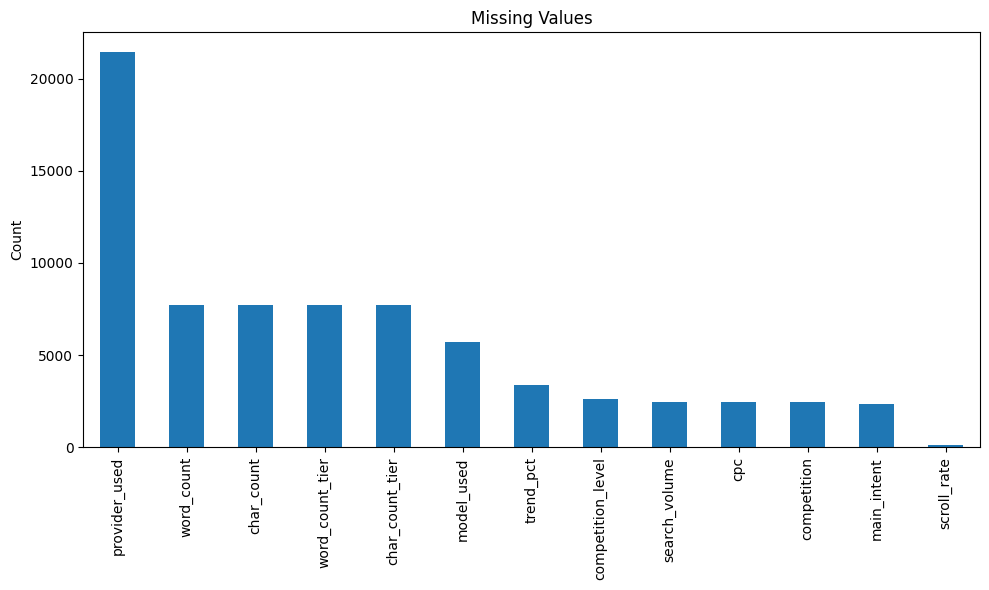

In [80]:
plt.figure(figsize=(10,6))

missing.plot(kind="bar")

plt.title("Missing Values")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


In [82]:
df.describe(include="object").T

,count,unique,top,freq
content_id,30000,30000,content_6880eb215048,1
client_id,30000,32,client_19581e27de,7008
competition_level,27390,3,LOW,22896
content_type,30000,3,keyword article,27207
main_intent,27626,4,informational,17235
provider_used,8562,2,google,7364
model_used,24267,5,gemini-3-flash-preview,13271
age_tier,30000,4,91-180,11780
freshness_tier,30000,4,0-30,20480
word_count_tier,22301,4,2000-3500,11263


In [83]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [84]:
df = df.drop_duplicates()

print(df.shape)

(30000, 44)


Numeric: 30
Categorical: 14


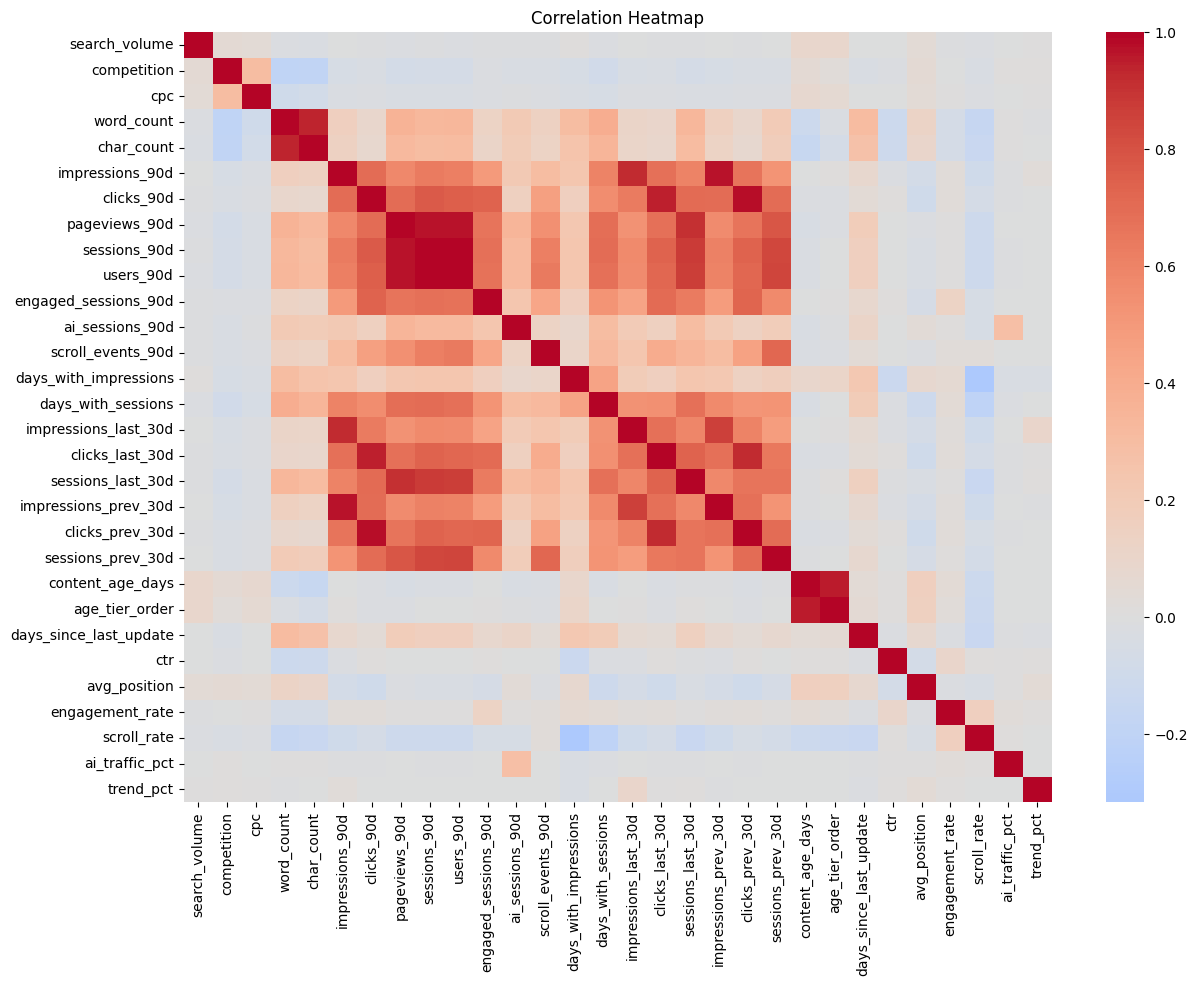

In [85]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
plt.figure(figsize=(14,10))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

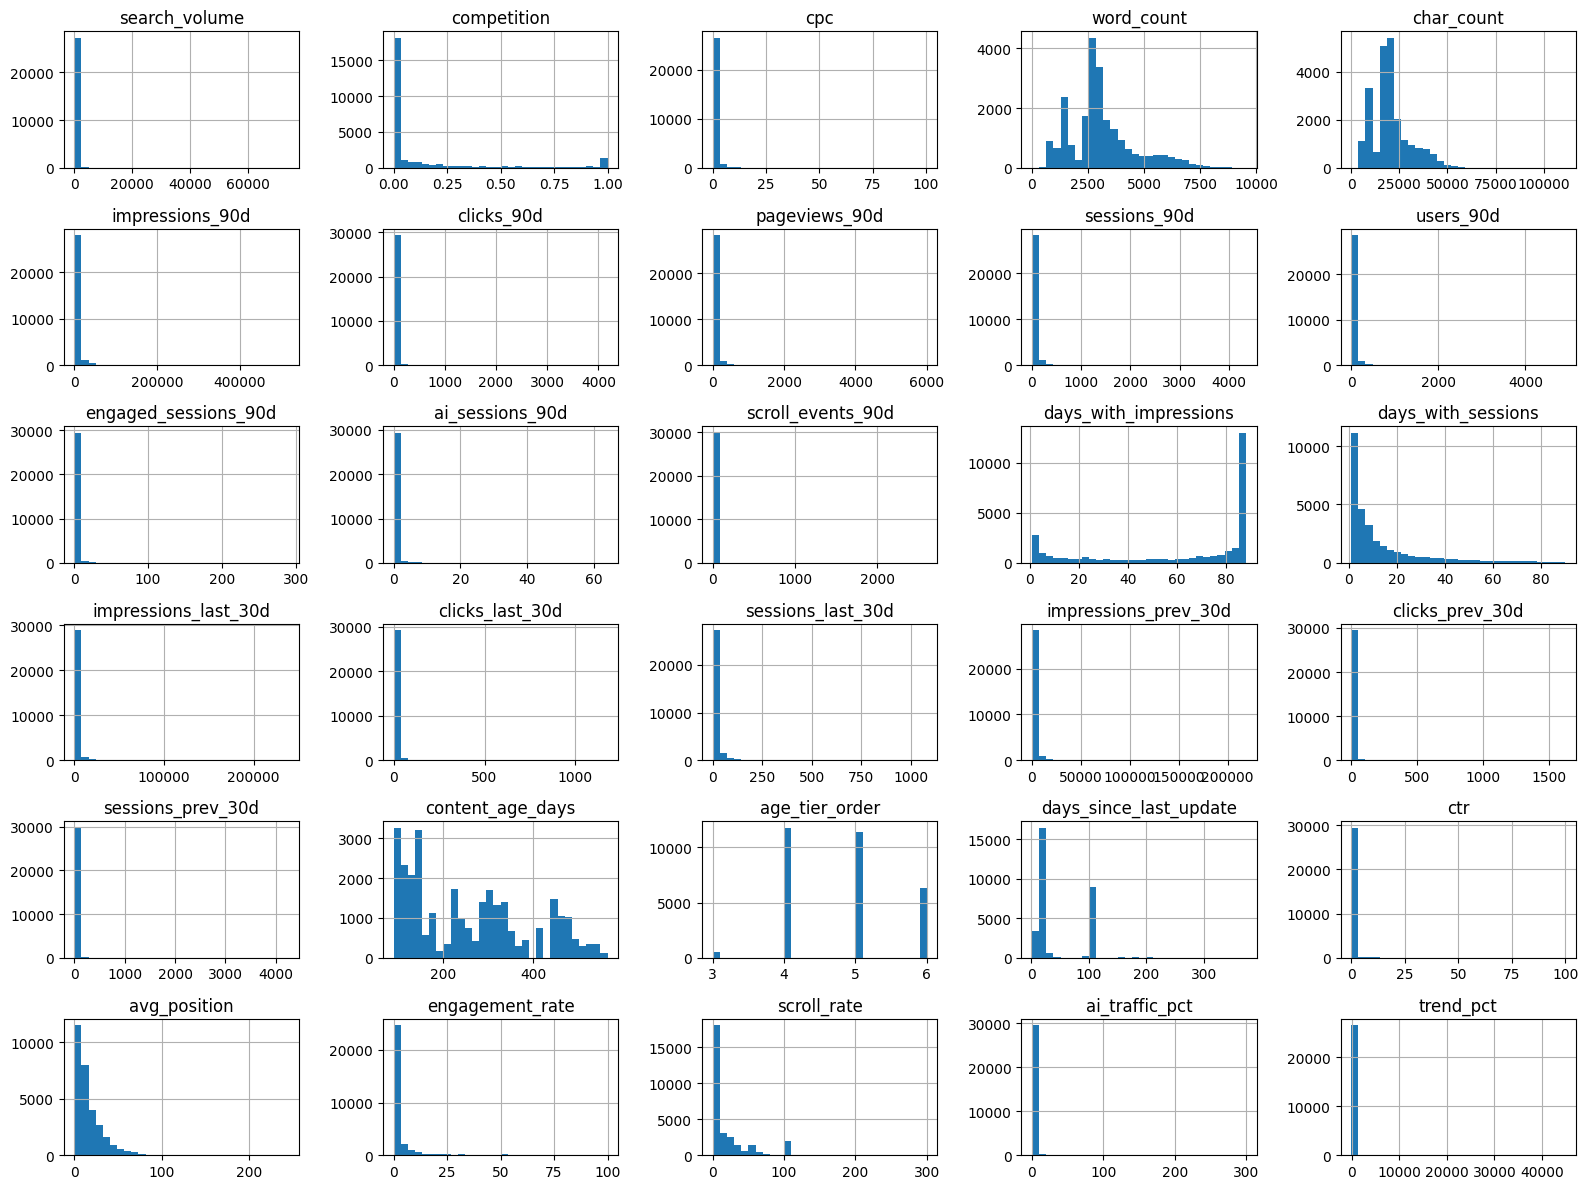

In [86]:
df[numeric_cols].hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()

plt.show()

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

## Baseline

The Week 4 baseline uses a rule-based weighted score:

- 40% content age
- 35% days since last update
- 25% negative traffic trend

The baseline provides a transparent reference point for the machine-learning model.

## Model

A Random Forest Regressor was selected because it can model nonlinear relationships and interactions between the available search, traffic, freshness, and engagement signals without requiring feature scaling.

The final feature set contains:

- content age
- days since last update
- search volume
- 90-day impressions
- 90-day clicks
- 90-day sessions
- CTR
- average position
- engagement rate

## Initial Validation

The Week 5 model used an 80/20 random train/test split.

The random-split results were:

| Metric | Random Split |
|---|---:|
| MAE | 0.0569 |
| RMSE | 0.0726 |
| R² | 0.6447 |

## Honest Validation

The model was subsequently evaluated using a grouped split based on `client_id`.

This prevents records from the same client from appearing in both training and testing sets and provides a more conservative estimate of generalization across clients.

The grouped validation results were:

| Metric | Grouped Split |
|---|---:|
| MAE | 0.0734 |
| RMSE | 0.0888 |
| R² | 0.5579 |

The grouped result is treated as the more conservative validation result.

## Leakage Checks

The final feature set was reviewed for target leakage.

The target `baseline_score` was not included as an input feature.

Identifier fields were excluded from the predictive feature set.

The analysis does not claim access to future ranking outcomes or private production signals unavailable to the modeling process.

## Interpretation

The model is evaluated as a decision-support component rather than as a causal model.

The objective is to rank potential refresh opportunities, not to prove that any particular feature causes changes in search performance.

In [87]:
import numpy as np

# Fill missing values used by the baseline
df["content_age_days"] = df["content_age_days"].fillna(0)
df["days_since_last_update"] = df["days_since_last_update"].fillna(0)
df["trend_pct"] = df["trend_pct"].fillna(0)

# Normalize freshness signals
df["age_score"] = (
    df["content_age_days"] /
    df["content_age_days"].max()
)

df["update_score"] = (
    df["days_since_last_update"] /
    df["days_since_last_update"].max()
)

negative_trend = np.maximum(-df["trend_pct"], 0)

max_negative_trend = negative_trend.max()

if max_negative_trend > 0:
    df["decline_score"] = (
        negative_trend / max_negative_trend
    )
else:
    df["decline_score"] = 0

# Week 4 baseline score
df["baseline_score"] = (
    0.40 * df["age_score"] +
    0.35 * df["update_score"] +
    0.25 * df["decline_score"]
)

print("Baseline score created successfully.")

df["baseline_score"].describe()

Baseline score created successfully.


,baseline_score
count,30000.000000
mean,0.306894
std,0.121034
min,0.065477
25%,0.224441
50%,0.316756
75%,0.386659
max,0.864539


In [88]:
features = [
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

X = df[features].fillna(0)
y = df["baseline_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 9)
y shape: (30000,)


In [89]:
# Display all columns
for col in df.columns:
    print(col)

content_id
client_id
search_volume
competition
competition_level
cpc
content_type
main_intent
word_count
char_count
provider_used
model_used
impressions_90d
clicks_90d
pageviews_90d
sessions_90d
users_90d
engaged_sessions_90d
ai_sessions_90d
scroll_events_90d
days_with_impressions
days_with_sessions
impressions_last_30d
clicks_last_30d
sessions_last_30d
impressions_prev_30d
clicks_prev_30d
sessions_prev_30d
content_age_days
age_tier
age_tier_order
days_since_last_update
freshness_tier
word_count_tier
char_count_tier
ctr
avg_position
engagement_rate
scroll_rate
ai_traffic_pct
impression_tier
position_tier
trend_direction
trend_pct
age_score
update_score
decline_score
baseline_score


In [90]:
# ================================
# Target Variable
# ================================

df["opportunity_score"] = (
    (df["impressions_prev_30d"] - df["impressions_last_30d"]) * 0.35 +
    (df["clicks_prev_30d"] - df["clicks_last_30d"]) * 0.35 +
    (df["avg_position"] * 2.0) +
    (df["days_since_last_update"] * 0.05)
)



df[["opportunity_score"]].describe()

,opportunity_score
count,30000.000000
mean,159.072025
std,1092.835266
min,-73769.800000
25%,17.100000
50%,55.000000
75%,136.562500
max,34322.350000


In [91]:
# ==================================
# Feature Selection
# ==================================



drop_columns = [
    "content_id",
    "client_id",
    target
]

X = df.drop(columns=drop_columns)

y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 46)
Target: (30000,)


In [92]:
# Numerical and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 34
Categorical Features: 12


In [93]:
# ============================================
# Load validated model and prepare features
# ============================================

import joblib
import pandas as pd
import numpy as np

# Load the validated Random Forest model
model_path = "/content/drive/MyDrive/flyrank-ml-internship/models/random_forest_model.pkl"

model = joblib.load(model_path)

print("Validated model loaded successfully.")

# Exact feature set used in Week 5
features = [
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

# Create feature matrix
X = df[features].fillna(0)

print("Feature matrix created.")
print("X shape:", X.shape)
print("Number of features:", len(features))

Validated model loaded successfully.
Feature matrix created.
X shape: (30000, 9)
Number of features: 9


In [94]:
predicted_scores = model.predict(X)

df["predicted_score"] = predicted_scores

print("Predictions generated successfully.")

df[
    ["content_id", "predicted_score"]
].head()

Predictions generated successfully.


,content_id,predicted_score
0,content_304f48230142,0.228573
1,content_a1fb4e703a9e,0.437715
2,content_9aa793d4d895,0.264378
3,content_331d6c4de07b,0.394421
4,content_d99b7a2d90ca,0.294881


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results

## Model Performance

The Random Forest model was first evaluated using a random 80/20 split and subsequently evaluated using a grouped split by client.

### Random Split

| Metric | Random Forest |
|---|---:|
| MAE | 0.0569 |
| RMSE | 0.0726 |
| R² | 0.6447 |

### Grouped Validation

| Metric | Random Forest |
|---|---:|
| MAE | 0.0734 |
| RMSE | 0.0888 |
| R² | 0.5579 |

The grouped validation result is more conservative because pages belonging to the same client were kept within either the training or testing group.

The decrease in R² from 0.6447 to 0.5579 indicates that the random-split estimate was somewhat optimistic about generalization.

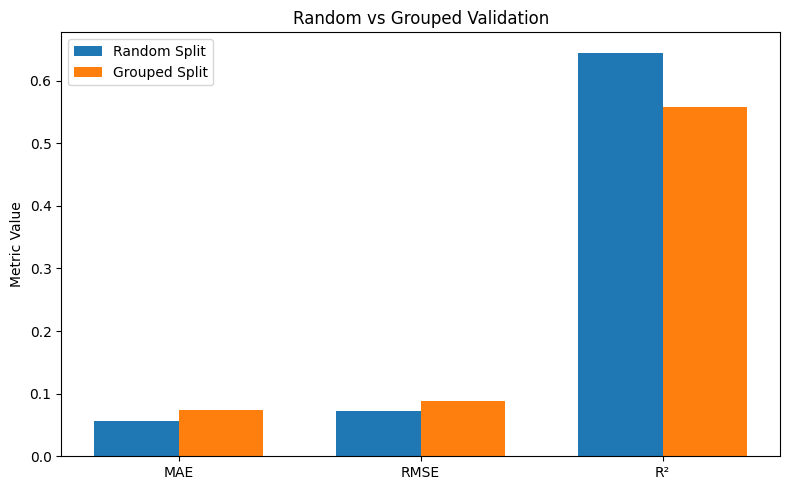

Saved: work/figures/validation_comparison.png


In [95]:
import matplotlib.pyplot as plt
import numpy as np
import os

metrics = ["MAE", "RMSE", "R²"]

random_values = [0.0569, 0.0726, 0.6447]
grouped_values = [0.0734, 0.0888, 0.5579]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    random_values,
    width,
    label="Random Split"
)

plt.bar(
    x + width / 2,
    grouped_values,
    width,
    label="Grouped Split"
)

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Random vs Grouped Validation")
plt.legend()

plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

plt.savefig(
    "work/figures/validation_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/validation_comparison.png")

# 4. Results

## Model Performance

The Random Forest model was initially evaluated against the rule-based baseline using the same random train/test split.

The model achieved:

| Approach | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest — Random Split | 0.0569 | 0.0726 | 0.6447 |

The grouped validation produced a more conservative result:

| Validation Strategy | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Split | 0.0569 | 0.0726 | 0.6447 |
| Grouped by Client | 0.0734 | 0.0888 | 0.5579 |

The grouped evaluation is more challenging and suggests that the random-split estimate may be somewhat optimistic.

## Feature Importance

The model's feature-importance analysis showed that `content_age_days` was the most influential feature, followed by `days_since_last_update`, `avg_position`, and `impressions_90d`.

This provides directional evidence that freshness and search-visibility signals were important to the model's predictions.

Feature importance should not be interpreted as proof of causal influence.

## 5. Limitations

*What this work cannot claim.*

# 5. Limitations and Honest Framing

This project has several important limitations.

### 1. The target is a rule-based score

The model predicts the project's baseline refresh-opportunity score rather than a future business outcome such as increased clicks, rankings, or conversions.

Therefore, good predictive performance does not demonstrate that the recommended actions will improve search performance.

### 2. Validation is not causal evidence

The analysis identifies statistical patterns in the available data.

It does not establish that content freshness, search visibility, engagement, or any other feature causes changes in Google rankings.

### 3. Generalization

The grouped validation result was weaker than the random-split result:

- Random split R²: 0.6447
- Grouped split R²: 0.5579

This indicates that validation design materially affects the estimated performance.

### 4. Missing business context

The available dataset may not contain important factors such as editorial priorities, business value, seasonal campaigns, content quality judgments, or strategic importance.

### 5. Human review is required

The model should be used as decision support.

Recommendations should be reviewed by a human before any content, SEO, URL, redirect, or publishing decision is made.

### Honest Claim

The results provide directional evidence that historical freshness, search, traffic, and engagement signals can support content-review prioritization.

They should not be interpreted as evidence of Google's ranking algorithm or as proof of causal refresh impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked Recommendations

The final model output was converted into a ranked content-action queue.

The queue prioritizes pages according to their predicted refresh-opportunity score and assigns human-readable reason codes.

## Recommended Action Types

| Signal / Archetype | Recommended Action |
|---|---|
| Old content with declining traffic | Refresh Content |
| Low CTR with reasonable ranking | Review Title & Meta Description |
| Poor search position | Review SEO / Search Visibility |
| Low engagement | Review Content Quality |
| Stable-performing content | Monitor |

## Content Decay / Refresh Insight

The model's feature-importance results indicate that freshness-related variables were particularly influential in the predictions.

This suggests that content age and time since the last update can be useful signals when prioritizing pages for editorial review.

However, this is a directional observation from the model and should not be interpreted as evidence that updating content will necessarily improve rankings.

## Action Queue

The ranked queue is intended to help editorial teams decide which pages to inspect first when review resources are limited.

Each recommendation should be reviewed against:

- content accuracy
- business importance
- search intent
- recent manual updates
- seasonal effects
- marketing campaigns
- current content quality

The model should not automatically publish, delete, redirect, merge, or modify content.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [96]:
import os
import json

# Create artifact directories
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Artifact directories ready.")

Artifact directories ready.


In [97]:
metrics = {
    "random_split": {
        "MAE": 0.0569,
        "RMSE": 0.0726,
        "R2": 0.6447

    },
    "grouped_split": {
        "MAE": 0.0734,
        "RMSE": 0.0888,
        "R2": 0.5579
    }
}

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("model_metrics.json created.")

model_metrics.json created.


In [98]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
import os

search_root = "/content/drive/MyDrive"

matches = []

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file.endswith((".pkl", ".joblib")):
            if "random" in file.lower() or "model" in file.lower():
                matches.append(os.path.join(root, file))

print("Possible model files:\n")

for path in matches:
    print(path)

Possible model files:

/content/drive/MyDrive/flyrank-ml-internship/models/random_forest_model.pkl


Model loaded successfully!
Feature Importance:


,Feature,Importance
0,content_age_days,0.517471
1,days_since_last_update,0.124382
7,avg_position,0.110929
3,impressions_90d,0.103586
5,sessions_90d,0.045781
2,search_volume,0.030957
6,ctr,0.029961
4,clicks_90d,0.023472
8,engagement_rate,0.013461


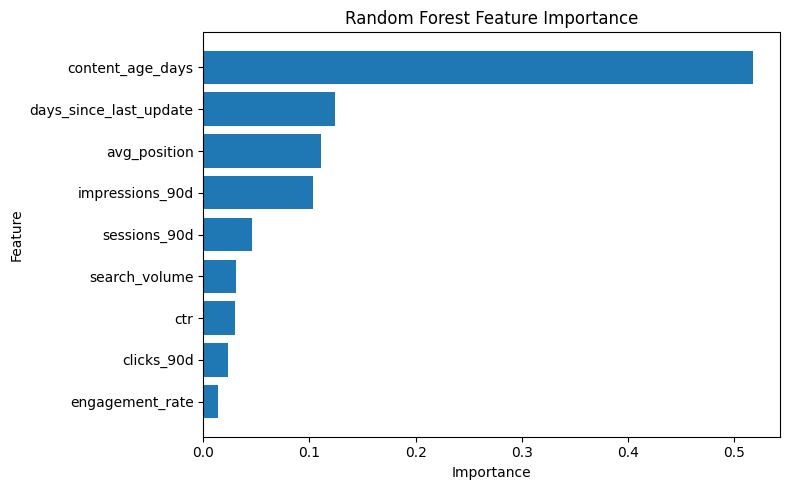

Saved: work/figures/feature_importance.png


In [100]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the saved Week 5 Random Forest model
model = joblib.load("/content/drive/MyDrive/flyrank-ml-internship/models/random_forest_model.pkl"
)

print("Model loaded successfully!")

# Features used by the Week 5 model
features = [
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

# Create feature importance table
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
display(importance)

# Create figures directory
os.makedirs("work/figures", exist_ok=True)

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

# Save figure
plt.savefig(
    "work/figures/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/feature_importance.png")

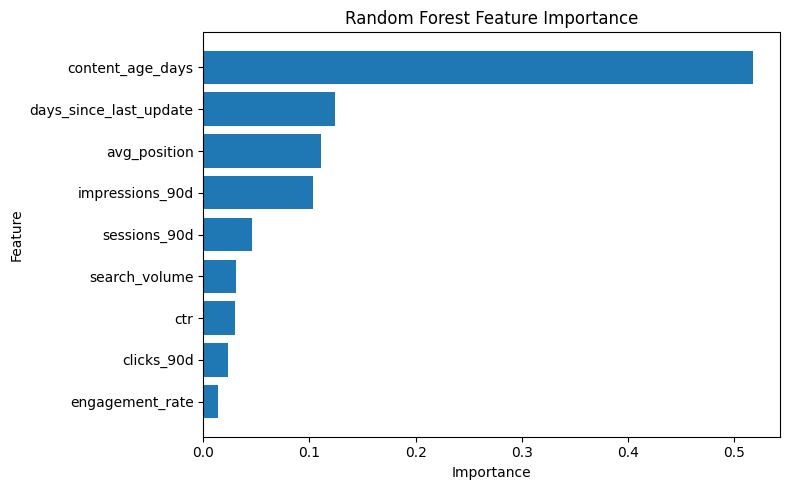

Feature importance figure saved successfully.


In [101]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

# Save figure for the paper
plt.savefig(
    "work/figures/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Feature importance figure saved successfully.")

In [102]:
import pandas as pd
import numpy as np
import joblib
import os

# --------------------------------------------------
# 1. Load the saved Week 5 model
# --------------------------------------------------

model_path = "/content/drive/MyDrive/flyrank-ml-internship/models/random_forest_model.pkl"

model = joblib.load(model_path)

print("Model loaded successfully!")


# --------------------------------------------------
# 2. Load the dataset
# --------------------------------------------------

data_path = "/content/drive/MyDrive/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

print("Dataset loaded:", df.shape)


# --------------------------------------------------
# 3. Define the SAME features used in Week 5
# --------------------------------------------------

features = [
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]


# --------------------------------------------------
# 4. Create X
# --------------------------------------------------

X = df[features].fillna(0)

print("Features prepared:", X.shape)


# --------------------------------------------------
# 5. Generate predicted refresh scores
# --------------------------------------------------

predicted_scores = model.predict(X)

df["predicted_score"] = predicted_scores

print("Predictions generated successfully!")

display(df[["content_id", "predicted_score"]].head())

Model loaded successfully!
Dataset loaded: (30000, 44)
Features prepared: (30000, 9)
Predictions generated successfully!


,content_id,predicted_score
0,content_304f48230142,0.228573
1,content_a1fb4e703a9e,0.437715
2,content_9aa793d4d895,0.264378
3,content_331d6c4de07b,0.394421
4,content_d99b7a2d90ca,0.294881


In [103]:
# --------------------------------------------------
# 6. Rank pages by predicted opportunity
# --------------------------------------------------

action_df = df.sort_values(
    "predicted_score",
    ascending=False
).copy()


# --------------------------------------------------
# 7. Reason codes
# --------------------------------------------------

def reason_code(row):

    if row["days_since_last_update"] > 180:
        return "Content has not been updated recently"

    elif row["ctr"] < 0.03:
        return "Low click-through rate"

    elif row["avg_position"] > 20:
        return "Low search visibility"

    elif row["engagement_rate"] < 0.40:
        return "Low engagement"

    else:
        return "General refresh opportunity"


# --------------------------------------------------
# 8. Recommended actions
# --------------------------------------------------

def recommended_action(row):

    if row["days_since_last_update"] > 180:
        return "Refresh Content"

    elif row["ctr"] < 0.03:
        return "Improve Title & Meta Description"

    elif row["avg_position"] > 20:
        return "Improve SEO"

    elif row["engagement_rate"] < 0.40:
        return "Improve Content Quality"

    else:
        return "Monitor"


action_df["Reason"] = action_df.apply(
    reason_code,
    axis=1
)

action_df["Recommended_Action"] = action_df.apply(
    recommended_action,
    axis=1
)


# --------------------------------------------------
# 9. Create top-20 ranked queue
# --------------------------------------------------

queue = action_df[
    [
        "content_id",
        "predicted_score",
        "Recommended_Action",
        "Reason",
        "days_since_last_update",
        "ctr",
        "avg_position"
    ]
].head(20)


# --------------------------------------------------
# 10. Export queue
# --------------------------------------------------

os.makedirs("work/outputs", exist_ok=True)

queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

print("Queue exported successfully!")

display(queue)

Queue exported successfully!


,content_id,predicted_score,Recommended_Action,Reason,days_since_last_update,ctr,avg_position
24216,content_1b4ec72dafd4,0.816550,Refresh Content,Content has not been updated recently,372,0.00,7.0
29384,content_f6fdf87348f6,0.808523,Refresh Content,Content has not been updated recently,373,0.00,32.5
26242,content_55a5b1c46474,0.805847,Refresh Content,Content has not been updated recently,373,0.00,7.5
18841,content_94991fe6268c,0.723828,Refresh Content,Content has not been updated recently,313,0.00,12.4
7509,content_7a888d3d99c8,0.717569,Refresh Content,Content has not been updated recently,313,0.00,67.6
19420,content_ccfb4d0227b1,0.716016,Refresh Content,Content has not been updated recently,301,0.00,10.8
24557,content_84d12054c0c0,0.705559,Refresh Content,Content has not been updated recently,304,0.00,8.0
21984,content_02b0d6e30129,0.695457,Refresh Content,Content has not been updated recently,313,0.00,6.9
23741,content_df1fa766cac2,0.689756,Refresh Content,Content has not been updated recently,304,0.49,4.8
18440,content_8d56efff1e71,0.688236,Refresh Content,Content has not been updated recently,372,0.00,35.0


In [104]:
import os

print("Artifacts:")
print(
    "model_metrics.json →",
    os.path.exists("work/outputs/model_metrics.json")
)

print(
    "feature_importance.png →",
    os.path.exists("work/figures/feature_importance.png")
)

print(
    "content_action_queue.csv →",
    os.path.exists("work/outputs/content_action_queue.csv")
)

Artifacts:
model_metrics.json → True
feature_importance.png → True
content_action_queue.csv → True


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.